In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/imdb_dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [ ]:
import os

folder_path = "/content/dataset/aclImdb/train/pos"
output_file = "/content/changed_dataset/train/pos_combined.txt"

# Create folders if they don't exist
os.makedirs(os.path.dirname(output_file), exist_ok=True)

with open(output_file, "w", encoding="utf-8") as outfile:
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        if os.path.isfile(file_path):
            with open(file_path, "r", encoding="utf-8", errors="ignore") as infile:
                outfile.write(infile.read())

            # Gap between files
            outfile.write("\n\n" + "="*60 + "\n\n")

print("✅ Done! File saved at:", output_file)

✅ Done! File saved at: /content/changed_dataset/train/pos_combined.txt


In [ ]:
import os

folder_path = "/content/dataset/aclImdb/train/neg"
output_file = "/content/changed_dataset/train/neg_combined.txt"

# Create folders if they don't exist
os.makedirs(os.path.dirname(output_file), exist_ok=True)

with open(output_file, "w", encoding="utf-8") as outfile:
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        if os.path.isfile(file_path):
            with open(file_path, "r", encoding="utf-8", errors="ignore") as infile:
                outfile.write(infile.read())

            # Gap between files
            outfile.write("\n\n" + "="*60 + "\n\n")

print("✅ Done! File saved at:", output_file)

✅ Done! File saved at: /content/changed_dataset/train/neg_combined.txt


Total reviews: 25000
Total sequences: 609754
X shape: (609754, 49)
y shape: (609754,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 49, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15000)          │     1,935,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,993,816 (11.42 MB)

 Trainable params: 2,993,816 (11.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
8575/8575 ━━━━━━━━━━━━━━━━━━━━ 93s 10ms/step - accuracy: 0.0878 - loss: 6.4206 - val_accuracy: 0.1485 - val_loss: 5.6421
Epoch 2/20
8575/8575 ━━━━━━━━━━━━━━━━━━━━ 88s 10ms/step - accuracy: 0.1573 - loss: 5.4183 - val_accuracy: 0.1659 - val_loss: 5.4432
Epoch 3/20
8575/8575 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.1786 - loss: 5.0813 - val_accuracy: 0.1749 - val_loss: 5.3710
Epoch 4/20
8575/8575 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.1942 - loss: 4.8391 - val_accuracy: 0.1804 - val_loss: 5.3655
Epoch 5/20
8575/8575 ━━━━━━━━━━━━━━━━━━━━ 87s 10ms/step - accuracy: 0.2060 - loss: 4.6493 - val_accuracy: 0.1831 - val_loss: 5.3799
Epoch 6/20
8575/8575 ━━━━━━━━━━━━━━━━━━━━ 87s 10ms/step - accuracy: 0.2161 - loss: 4.4815 - val_accuracy: 0.1837 - val_loss: 5.4260
Epoch 7/20
8575/8575 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.2270 - loss: 4.3495 - val_accuracy: 0.1845 - val_loss: 5.4689
Model and tokenizer saved!


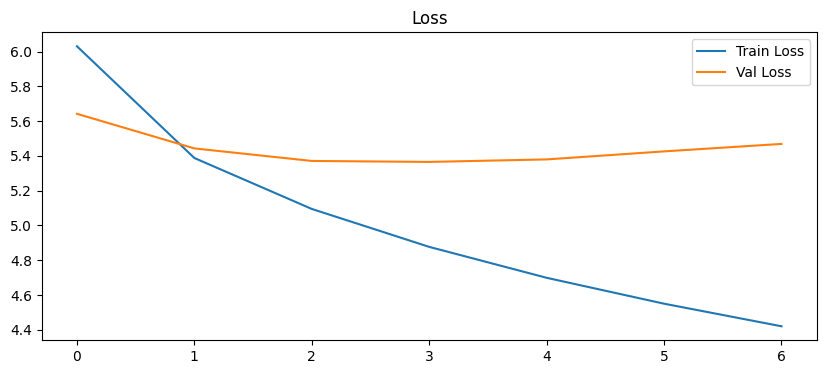

In [ ]:
import re
import numpy as np
import pickle
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# ---------- CONFIG ----------
FILE_PATH = "/content/changed_dataset/train/pos_combined.txt"
VOCAB_SIZE = 15000
MAX_SEQ_LEN = 50      # FIXED length
EMBED_DIM = 64
LSTM_UNITS = 128
BATCH_SIZE = 64
EPOCHS = 20

# ---------- PREPROCESS ----------
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

raw_reviews = re.split(r"\n\s*\n", raw_text)
reviews = [preprocess_text(r) for r in raw_reviews if len(r.strip()) > 0]

print("Total reviews:", len(reviews))

# ---------- TOKENIZE ----------
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(reviews)

sequences = tokenizer.texts_to_sequences(reviews)

# ---------- BUILD N-GRAM SEQUENCES ----------
input_sequences = []

for seq in sequences:
    for i in range(1, min(len(seq), MAX_SEQ_LEN)):
        n_gram = seq[:i+1]
        input_sequences.append(n_gram)

print("Total sequences:", len(input_sequences))

# ---------- PAD ----------
input_sequences = pad_sequences(
    input_sequences,
    maxlen=MAX_SEQ_LEN,
    padding="pre"
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

# ---------- MODEL (FIXED FOR KERAS 3) ----------
model = Sequential([
    Input(shape=(MAX_SEQ_LEN - 1,)),   # ✅ IMPORTANT FIX
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    LSTM(LSTM_UNITS),
    Dense(VOCAB_SIZE, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()   # ✅ Now shows proper shapes + params

# ---------- TRAIN ----------
early_stop = EarlyStopping(monitor="val_loss", patience=3)

history = model.fit(
    X,
    y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop]
)

# ---------- SAVE ----------
model.save("/content/positive_model1.keras")

with open("/content/pos_tokenizer1.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Model and tokenizer saved!")

# ---------- PLOT ----------
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

Total reviews: 25000
Total sequences: 610450
X shape: (610450, 49)
y shape: (610450,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 49, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15000)          │     1,935,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,993,816 (11.42 MB)

 Trainable params: 2,993,816 (11.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
8585/8585 ━━━━━━━━━━━━━━━━━━━━ 88s 10ms/step - accuracy: 0.0877 - loss: 6.3592 - val_accuracy: 0.1491 - val_loss: 5.5301
Epoch 2/20
8585/8585 ━━━━━━━━━━━━━━━━━━━━ 87s 10ms/step - accuracy: 0.1583 - loss: 5.3631 - val_accuracy: 0.1659 - val_loss: 5.3263
Epoch 3/20
8585/8585 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.1768 - loss: 5.0528 - val_accuracy: 0.1755 - val_loss: 5.2566
Epoch 4/20
8585/8585 ━━━━━━━━━━━━━━━━━━━━ 87s 10ms/step - accuracy: 0.1912 - loss: 4.8277 - val_accuracy: 0.1801 - val_loss: 5.2523
Epoch 5/20
8585/8585 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.2035 - loss: 4.6462 - val_accuracy: 0.1836 - val_loss: 5.2657
Epoch 6/20
8585/8585 ━━━━━━━━━━━━━━━━━━━━ 87s 10ms/step - accuracy: 0.2146 - loss: 4.4876 - val_accuracy: 0.1821 - val_loss: 5.3090
Epoch 7/20
8585/8585 ━━━━━━━━━━━━━━━━━━━━ 86s 10ms/step - accuracy: 0.2239 - loss: 4.3526 - val_accuracy: 0.1822 - val_loss: 5.3564
Model and tokenizer saved!


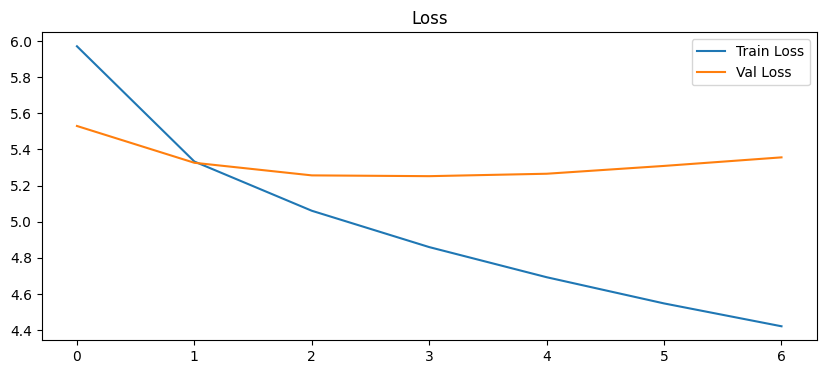

In [ ]:
import re
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# ---------- CONFIG ----------
FILE_PATH = "/content/changed_dataset/train/neg_combined.txt"
VOCAB_SIZE = 15000
MAX_SEQ_LEN = 50      # FIXED length (important!)
EMBED_DIM = 64
LSTM_UNITS = 128
BATCH_SIZE = 64
EPOCHS = 20

# ---------- PREPROCESS ----------
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

with open(FILE_PATH, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

raw_reviews = re.split(r"\n\s*\n", raw_text)
reviews = [preprocess_text(r) for r in raw_reviews if len(r.strip()) > 0]

print("Total reviews:", len(reviews))

# ---------- TOKENIZE ----------
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(reviews)

sequences = tokenizer.texts_to_sequences(reviews)

# ---------- BUILD SEQUENCES (SAFE VERSION) ----------
input_sequences = []

for seq in sequences:
    for i in range(1, min(len(seq), MAX_SEQ_LEN)):
        n_gram = seq[:i+1]
        input_sequences.append(n_gram)

print("Total sequences:", len(input_sequences))

input_sequences = pad_sequences(
    input_sequences,
    maxlen=MAX_SEQ_LEN,
    padding="pre"
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

# ---------- MODEL (FIXED FOR KERAS 3) ----------
model = Sequential([
    Input(shape=(MAX_SEQ_LEN - 1,)),   
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    LSTM(LSTM_UNITS),
    Dense(VOCAB_SIZE, activation="softmax")
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()   # ✅ Now shows proper shapes + params

# ---------- TRAIN ----------
early_stop = EarlyStopping(monitor="val_loss", patience=3)

history = model.fit(
    X,
    y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop]
)

# ---------- SAVE ----------
model.save("/content/negative_model1.keras")
with open("/content/neg_tokenizer1.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Model and tokenizer saved!")

# ---------- PLOT ----------
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_SEQ_LEN = 50

index_word = {v: k for k, v in tokenizer.word_index.items()}

# ---------- TOP-K SAMPLING ----------
def top_k_sampling(preds, k=10):

    preds = np.asarray(preds).astype("float64")

    top_k_indices = np.argsort(preds)[-k:]

    top_k_probs = preds[top_k_indices]

    top_k_probs = top_k_probs / np.sum(top_k_probs)

    return np.random.choice(top_k_indices, p=top_k_probs)


# ---------- GENERATE TEXT ----------
def generate_text(seed_text, next_words=15):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=MAX_SEQ_LEN - 1,
            padding="pre"
        )

        preds = model.predict(token_list, verbose=0)[0]

        next_index = top_k_sampling(preds, k=10)

        next_word = index_word.get(next_index, "")

        if next_word == "":
            break

        seed_text += " " + next_word

    return seed_text

In [ ]:
from google.colab import files

files.download("/content/positive_model1.keras")
files.download("/content/negative_model1.keras")
files.download("/content/pos_tokenizer1.pkl")
files.download("/content/neg_tokenizer1.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>